# Mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports

In [3]:
# Cell 1: Install dependencies
# !apt-get install -y python3-gdal
# !pip install rasterio geopandas tqdm matplotlib scipy

# Cell 2: Verify installation
import rasterio
import geopandas as gpd
print(f"rasterio version: {rasterio.__version__}")
print(f"geopandas version: {gpd.__version__}")
print("✅ All packages installed successfully!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-numpy
Suggested packages:
  gdal-bin python-numpy-doc python3-dev python3-pytest
The following NEW packages will be installed:
  python3-gdal python3-numpy
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 4,562 kB of archives.
After this operation, 24.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Fetched 4,562 kB in 3s (1,367 kB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../python3-numpy_1%3a1.21.5-1ubuntu22.04.1_amd64.deb ...
Unpacking python3-numpy (1:1.2

In [4]:
"""
SAR Water Segmentation with Vision Transformer
===============================================
Complete pipeline for water body segmentation from 2-band SAR imagery using ViT.

This implementation uses a Vision Transformer encoder with a segmentation head
for pixel-level water classification.

Author: Claude
Date: 2026-04-18
"""

import os
import random
from typing import Dict, List, Tuple, Optional

# import warnings
# warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import rasterio
from rasterio import features
import geopandas as gpd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

## Version

In [5]:
# Run this in Colab to check versions
import sys
import importlib

print("=" * 50)
print("COLAB VERSION CHECK")
print("=" * 50)

# Core packages
packages = ['torch', 'torchvision', 'numpy', 'scipy', 'matplotlib', 'tqdm']

for pkg in packages:
    try:
        module = importlib.import_module(pkg)
        print(f"{pkg:12} : {module.__version__}")
    except:
        print(f"{pkg:12} : NOT INSTALLED")

# Geospatial (these need to be installed manually in Colab)
geopackages = ['rasterio', 'geopandas']
print("\n" + "-" * 50)
print("Geospatial packages (may need installation):")
for pkg in geopackages:
    try:
        module = importlib.import_module(pkg)
        print(f"{pkg:12} : {module.__version__}")
    except:
        print(f"{pkg:12} : NOT INSTALLED")

print("\n" + "-" * 50)
print(f"Python: {sys.version.split()[0]}")
print(f"CUDA: {torch.cuda.is_available() if 'torch' in sys.modules else 'Unknown'}")

COLAB VERSION CHECK
torch        : 2.9.0+cpu
torchvision  : 0.24.0+cpu
numpy        : 2.0.2
scipy        : 1.16.3
matplotlib   : 3.10.0
tqdm         : 4.67.3

--------------------------------------------------
Geospatial packages (may need installation):
rasterio     : 1.5.0
geopandas    : 1.1.3

--------------------------------------------------
Python: 3.12.13
CUDA: False


In [6]:
'''
==================================================
COLAB VERSION CHECK
==================================================
torch        : 2.10.0+cpu
torchvision  : 0.25.0+cpu
numpy        : 2.0.2
scipy        : 1.16.3
matplotlib   : 3.10.0
tqdm         : 4.67.3

--------------------------------------------------
Geospatial packages (may need installation):
rasterio     : 1.5.0
geopandas    : 1.1.3

--------------------------------------------------
Python: 3.12.13
CUDA: False
'''

'\n==================================================\nCOLAB VERSION CHECK\n==================================================\ntorch        : 2.10.0+cpu\ntorchvision  : 0.25.0+cpu\nnumpy        : 2.0.2\nscipy        : 1.16.3\nmatplotlib   : 3.10.0\ntqdm         : 4.67.3\n\n--------------------------------------------------\nGeospatial packages (may need installation):\nrasterio     : 1.5.0\ngeopandas    : 1.1.3\n\n--------------------------------------------------\nPython: 3.12.13\nCUDA: False\n'

# Configuration

In [7]:
# ============================================
# Configuration
# ============================================

class Config:
    """Central configuration for the training pipeline"""

    # Paths
    BASE_PATH = "/content/drive/MyDrive/SAR_water_images_and_labels"
    IMAGES_FOLDER = "images"
    LABELS_FOLDER = "labels"

    # Model Architecture
    NUM_CLASSES = 1  # Binary segmentation (water vs non-water)
    INPUT_BANDS = 2  # VV and VH bands
    IMAGE_SIZE = 512  # Input image size (512x512)
    PATCH_SIZE = 16  # Size of patches for ViT
    EMBED_DIM = 768  # Embedding dimension
    NUM_HEADS = 12  # Number of attention heads
    NUM_LAYERS = 12  # Number of transformer layers
    MLP_RATIO = 4  # MLP expansion ratio
    DROPOUT = 0.1  # Dropout rate

    # Training Hyperparameters
    BATCH_SIZE = 4
    NUM_EPOCHS = 100
    LEARNING_RATE = 3e-4
    WEIGHT_DECAY = 0.01
    NUM_WORKERS = 2

    # Data Augmentation
    AUGMENT_PROB = 0.85  # Probability of applying augmentation
    FLIP_PROB = 0.5
    ROTATION_PROB = 0.7
    BRIGHTNESS_PROB = 0.4
    NOISE_PROB = 0.3
    ELASTIC_PROB = 0.2

    # Scheduler
    WARMUP_EPOCHS = 5
    SCHEDULER_PATIENCE = 10
    SCHEDULER_FACTOR = 0.5
    MIN_LR = 1e-6

    # Inference
    INFERENCE_THRESHOLD = 0.5

    # Device
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    @classmethod
    def get_paths(cls):
        """Get all path configurations"""
        return {
            "base": cls.BASE_PATH,
            "images": os.path.join(cls.BASE_PATH, cls.IMAGES_FOLDER),
            "labels": os.path.join(cls.BASE_PATH, cls.LABELS_FOLDER),
            "best_model": os.path.join(cls.BASE_PATH, "vit_best_model.pth"),
            "final_model": os.path.join(cls.BASE_PATH, "vit_final_model.pth"),
        }

# ViT Model

## Vision Transformer Components

In [8]:
# ============================================
# Vision Transformer Components
# ============================================


class PatchEmbedding(nn.Module):
    """
    Split image into patches and embed them.

    Args:
        image_size: Input image size (assumed square)
        patch_size: Size of each patch
        in_channels: Number of input channels
        embed_dim: Embedding dimension
    """

    def __init__(
        self,
        image_size: int = 512,
        patch_size: int = 16,
        in_channels: int = 2,
        embed_dim: int = 768,
    ):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        # Patch embedding via convolution
        self.projection = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, C, H, W)
        Returns:
            (B, num_patches, embed_dim)
        """
        # x: (B, 2, 512, 512) -> (B, 768, 32, 32)
        x = self.projection(x)
        # (B, 768, 32, 32) -> (B, 768, 1024) -> (B, 1024, 768)
        x = x.flatten(2).transpose(1, 2)
        return x


class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head self-attention mechanism.

    Args:
        embed_dim: Embedding dimension
        num_heads: Number of attention heads
        dropout: Dropout probability
    """

    def __init__(self, embed_dim: int = 768, num_heads: int = 12, dropout: float = 0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim**-0.5

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, N, embed_dim)
        Returns:
            (B, N, embed_dim)
        """
        B, N, C = x.shape

        # Generate Q, K, V
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, num_heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Attention
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)

        # Combine heads
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.dropout(x)

        return x


class MLP(nn.Module):
    """
    Feed-forward network.

    Args:
        in_features: Input dimension
        hidden_features: Hidden layer dimension
        dropout: Dropout probability
    """

    def __init__(
        self,
        in_features: int,
        hidden_features: Optional[int] = None,
        dropout: float = 0.1,
    ):
        super().__init__()
        hidden_features = hidden_features or in_features * 4

        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


class TransformerBlock(nn.Module):
    """
    Transformer encoder block.

    Args:
        embed_dim: Embedding dimension
        num_heads: Number of attention heads
        mlp_ratio: MLP expansion ratio
        dropout: Dropout probability
    """

    def __init__(
        self,
        embed_dim: int = 768,
        num_heads: int = 12,
        mlp_ratio: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, int(embed_dim * mlp_ratio), dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Self-attention with residual
        x = x + self.attn(self.norm1(x))
        # MLP with residual
        x = x + self.mlp(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    """
    Vision Transformer Encoder.

    Args:
        image_size: Input image size
        patch_size: Patch size
        in_channels: Number of input channels
        embed_dim: Embedding dimension
        num_layers: Number of transformer layers
        num_heads: Number of attention heads
        mlp_ratio: MLP expansion ratio
        dropout: Dropout probability
    """

    def __init__(
        self,
        image_size: int = 512,
        patch_size: int = 16,
        in_channels: int = 2,
        embed_dim: int = 768,
        num_layers: int = 12,
        num_heads: int = 12,
        mlp_ratio: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            image_size, patch_size, in_channels, embed_dim
        )

        num_patches = self.patch_embed.num_patches

        # Positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        # Transformer blocks
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
                for _ in range(num_layers)
            ]
        )

        self.norm = nn.LayerNorm(embed_dim)

        # Initialize positional embeddings
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, C, H, W)
        Returns:
            (B, num_patches, embed_dim)
        """
        # Patch embedding
        x = self.patch_embed(x)

        # Add positional embedding
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # Apply transformer blocks
        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        return x


class SegmentationHead(nn.Module):
    """
    Segmentation decoder head for ViT.

    Upsamples the patch embeddings back to image resolution.

    Args:
        embed_dim: Embedding dimension from encoder
        num_classes: Number of output classes
        image_size: Output image size
        patch_size: Patch size used in encoder
    """

    def __init__(
        self,
        embed_dim: int = 768,
        num_classes: int = 1,
        image_size: int = 512,
        patch_size: int = 16,
    ):
        super().__init__()

        self.num_patches_per_side = image_size // patch_size
        self.patch_size = patch_size

        # Decoder layers with progressive upsampling
        self.decoder = nn.Sequential(
            # (B, 768, 32, 32) -> (B, 512, 32, 32)
            nn.Conv2d(embed_dim, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            # (B, 512, 32, 32) -> (B, 512, 64, 64)
            nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            # (B, 512, 64, 64) -> (B, 256, 128, 128)
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # (B, 256, 128, 128) -> (B, 128, 256, 256)
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # (B, 128, 256, 256) -> (B, 64, 512, 512)
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # Final classification layer
            nn.Conv2d(64, num_classes, kernel_size=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, num_patches, embed_dim)
        Returns:
            (B, num_classes, H, W)
        """
        B, N, C = x.shape
        H = W = self.num_patches_per_side

        # Reshape to spatial format
        x = x.transpose(1, 2).reshape(B, C, H, W)

        # Decode
        x = self.decoder(x)

        return x

## Model

In [9]:
class ViTSegmentationModel(nn.Module):
    """
    Complete Vision Transformer model for semantic segmentation.

    Args:
        image_size: Input image size
        patch_size: Patch size
        in_channels: Number of input channels
        num_classes: Number of output classes
        embed_dim: Embedding dimension
        num_layers: Number of transformer layers
        num_heads: Number of attention heads
        mlp_ratio: MLP expansion ratio
        dropout: Dropout probability
    """

    def __init__(
        self,
        image_size: int = 512,
        patch_size: int = 16,
        in_channels: int = 2,
        num_classes: int = 1,
        embed_dim: int = 768,
        num_layers: int = 12,
        num_heads: int = 12,
        mlp_ratio: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.encoder = ViTEncoder(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
            num_layers=num_layers,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )

        self.decoder = SegmentationHead(
            embed_dim=embed_dim,
            num_classes=num_classes,
            image_size=image_size,
            patch_size=patch_size,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input tensor of shape (B, C, H, W)
        Returns:
            Output tensor of shape (B, num_classes, H, W)
        """
        # Encode
        x = x.float()

        features = self.encoder(x)

        # Decode
        output = self.decoder(features)

        return output

    def get_num_parameters(self) -> int:
        """Return total number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Dataset

In [10]:
# ============================================
# Dataset
# ============================================

class SARSegmentationDataset(Dataset):
    """
    Dataset for 2-band SAR images with shapefile labels.

    Args:
        image_paths: List of paths to SAR image files
        shapefile_paths: List of paths to corresponding shapefile labels
        target_size: Target size for resizing (height, width)
        augment: Whether to apply data augmentation
        augment_prob: Probability of applying augmentation
    """

    def __init__(
        self,
        image_paths: List[str],
        shapefile_paths: List[str],
        target_size: int = 512,
        augment: bool = False,
        augment_prob: float = 0.8,
    ):
        assert len(image_paths) == len(
            shapefile_paths
        ), "Number of images and shapefiles must match"

        self.image_paths = image_paths
        self.shapefile_paths = shapefile_paths
        self.target_size = target_size
        self.augment = augment
        self.augment_prob = augment_prob

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Get a single sample.

        Returns:
            image: Tensor of shape (2, H, W)
            mask: Tensor of shape (1, H, W)
        """
        # Load image and mask
        image = self._load_sar_image(self.image_paths[idx])
        mask = self._shapefile_to_mask(self.shapefile_paths[idx], self.image_paths[idx])

        # Convert to tensors
        image_tensor = torch.from_numpy(image).float()
        mask_tensor = torch.from_numpy(mask).float()

        # Resize to target size
        image_tensor = self._resize_image(image_tensor)
        mask_tensor = self._resize_mask(mask_tensor)

        # Apply augmentations
        if self.augment and random.random() < self.augment_prob:
            image_tensor, mask_tensor = self._apply_augmentations(
                image_tensor, mask_tensor
            )

        # Add channel dimension to mask
        mask_tensor = mask_tensor.unsqueeze(0)  # (H, W) -> (1, H, W)

        return image_tensor, mask_tensor

    def _load_sar_image(self, image_path: str) -> np.ndarray:
        """
        Load and normalize SAR image to 2 bands.

        Returns:
            Array of shape (2, H, W) normalized to [0, 1]
        """
        with rasterio.open(image_path) as src:
            img = src.read()

        # Ensure exactly 2 bands
        if img.shape[0] > 2:
            img = img[:2]
        elif img.shape[0] == 1:
            img = np.repeat(img, 2, axis=0)

        # Normalize each band independently to [0, 1]
        normalized = np.zeros_like(img, dtype=np.float32)
        for i in range(2):
            band_min, band_max = img[i].min(), img[i].max()
            if band_max > band_min:
                normalized[i] = (img[i] - band_min) / (band_max - band_min)
            else:
                normalized[i] = img[i]

        return normalized

    def _shapefile_to_mask(
        self, shapefile_path: str, reference_image_path: str
    ) -> np.ndarray:
        """
        Convert shapefile polygons to binary raster mask.

        Returns:
            Binary mask array of shape (H, W)
        """
        # Get spatial reference from image
        with rasterio.open(reference_image_path) as src:
            transform = src.transform
            shape = (src.height, src.width)

        # Read shapefile
        gdf = gpd.read_file(shapefile_path)

        # Create binary mask
        if len(gdf) > 0:
            geometries = [(geom, 1) for geom in gdf.geometry]
            mask = features.rasterize(
                geometries, out_shape=shape, transform=transform, fill=0, dtype=np.uint8
            )
        else:
            mask = np.zeros(shape, dtype=np.uint8)

        return mask

    def _resize_image(self, image: torch.Tensor) -> torch.Tensor:
        """Resize image to target size using bilinear interpolation"""
        # Add batch dimension
        image = image.unsqueeze(0)
        # Resize
        image = F.interpolate(
            image,
            size=(self.target_size, self.target_size),
            mode="bilinear",
            align_corners=False,
        )
        # Remove batch dimension
        return image.squeeze(0)

    def _resize_mask(self, mask: torch.Tensor) -> torch.Tensor:
        """Resize mask to target size using nearest neighbor"""
        # Add batch and channel dimensions
        mask = mask.unsqueeze(0).unsqueeze(0)
        # Resize
        mask = F.interpolate(
            mask, size=(self.target_size, self.target_size), mode="nearest"
        )
        # Remove batch and channel dimensions
        return mask.squeeze(0).squeeze(0)

    def _apply_augmentations(
        self, image: torch.Tensor, mask: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Apply random augmentations to image and mask.

        Args:
            image: (2, H, W)
            mask: (H, W)
        Returns:
            Augmented image and mask
        """
        image_np = image.numpy()
        mask_np = mask.numpy()

        # Random horizontal flip
        if random.random() < Config.FLIP_PROB:
            image_np = np.flip(image_np, axis=2).copy()
            mask_np = np.flip(mask_np, axis=1).copy()

        # Random vertical flip
        if random.random() < Config.FLIP_PROB:
            image_np = np.flip(image_np, axis=1).copy()
            mask_np = np.flip(mask_np, axis=0).copy()

        # Random rotation (90, 180, 270 degrees)
        if random.random() < Config.ROTATION_PROB:
            k = random.randint(1, 3)
            image_np = np.rot90(image_np, k=k, axes=(1, 2)).copy()
            mask_np = np.rot90(mask_np, k=k, axes=(0, 1)).copy()

        # Random brightness adjustment
        if random.random() < Config.BRIGHTNESS_PROB:
            factor = random.uniform(0.8, 1.2)
            image_np = np.clip(image_np * factor, 0, 1)

        # Random noise
        if random.random() < Config.NOISE_PROB:
            noise = np.random.normal(0, 0.02, image_np.shape)
            image_np = np.clip(image_np + noise, 0, 1)

        return torch.from_numpy(image_np), torch.from_numpy(mask_np)

# Loss Functions

In [11]:
# ============================================
# Loss Functions
# ============================================


class DiceLoss(nn.Module):
    """
    Dice loss for binary segmentation.
    """

    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            predictions: (B, 1, H, W) logits
            targets: (B, 1, H, W) binary targets
        """
        # Apply sigmoid to get probabilities
        predictions = torch.sigmoid(predictions)

        # Flatten
        predictions = predictions.view(-1)
        targets = targets.view(-1)

        # Dice coefficient
        intersection = (predictions * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (
            predictions.sum() + targets.sum() + self.smooth
        )

        return 1 - dice


class CombinedLoss(nn.Module):
    """
    Combined Binary Cross Entropy and Dice Loss.
    """

    def __init__(self, bce_weight: float = 0.5, dice_weight: float = 0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = self.bce(predictions, targets)
        dice_loss = self.dice(predictions, targets)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

# Trainer

In [12]:
# ============================================
# Trainer
# ============================================


class Trainer:
    """
    Training manager for the segmentation model.

    Args:
        model: Model to train
        train_loader: Training data loader
        config: Configuration object
    """

    def __init__(self, model: nn.Module, train_loader: DataLoader, config: Config):
        self.model = model.to(config.DEVICE)
        self.train_loader = train_loader
        self.config = config
        self.device = config.DEVICE

        # Loss function
        self.criterion = CombinedLoss()

        # Optimizer
        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY,
        )

        # Learning rate scheduler
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode="min",
            factor=config.SCHEDULER_FACTOR,
            patience=config.SCHEDULER_PATIENCE,
            min_lr=config.MIN_LR,
            # verbose=True,
        )

        # Training history
        self.history = {"train_loss": [], "learning_rate": []}

        self.best_loss = float("inf")

    def train(self, num_epochs: Optional[int] = None) -> Dict:
        """
        Train the model.

        Args:
            num_epochs: Number of epochs (uses config if None)

        Returns:
            Training history dictionary
        """
        num_epochs = num_epochs or self.config.NUM_EPOCHS

        print(f"\n{'='*60}")
        print(f"Starting training on {self.device}")
        print(f"{'='*60}\n")

        for epoch in range(num_epochs):
            # Train one epoch
            epoch_loss = self._train_epoch(epoch, num_epochs)

            # Update learning rate
            self.scheduler.step(epoch_loss)
            current_lr = self.optimizer.param_groups[0]["lr"]

            # Save history
            self.history["train_loss"].append(epoch_loss)
            self.history["learning_rate"].append(current_lr)

            # Save best model
            if epoch_loss < self.best_loss:
                self.best_loss = epoch_loss
                self._save_checkpoint("best")
                print(f"   ✅ New best model saved! (loss: {epoch_loss:.4f})")

            # Print progress
            print(
                f"   Epoch [{epoch+1}/{num_epochs}] - "
                f"Loss: {epoch_loss:.4f} - "
                f"LR: {current_lr:.2e}"
            )

        print(f"\n{'='*60}")
        print("Training completed!")
        print(f"Best loss: {self.best_loss:.4f}")
        print(f"{'='*60}\n")

        return self.history

    def _train_epoch(self, epoch: int, total_epochs: int) -> float:
        """Train for one epoch"""
        self.model.train()
        total_loss = 0.0

        pbar = tqdm(
            self.train_loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False
        )

        for batch_idx, (images, masks) in enumerate(pbar):
            # Move to device
            images = images.to(self.device)
            masks = masks.to(self.device)

            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)

            # Backward pass
            loss.backward()
            self.optimizer.step()

            # Update metrics
            total_loss += loss.item()
            pbar.set_postfix({"loss": loss.item()})

        return total_loss / len(self.train_loader)

    def _save_checkpoint(self, checkpoint_type: str = "best"):
        """Save model checkpoint"""
        paths = self.config.get_paths()
        save_path = (
            paths["best_model"] if checkpoint_type == "best" else paths["final_model"]
        )

        checkpoint = {
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "best_loss": self.best_loss,
            "history": self.history,
            "config": {
                "image_size": self.config.IMAGE_SIZE,
                "patch_size": self.config.PATCH_SIZE,
                "embed_dim": self.config.EMBED_DIM,
                "num_layers": self.config.NUM_LAYERS,
                "num_heads": self.config.NUM_HEADS,
                "num_classes": self.config.NUM_CLASSES,
                "in_channels": self.config.INPUT_BANDS,
            },
        }

        torch.save(checkpoint, save_path)

    def plot_history(self, save_path: Optional[str] = None):
        """Plot training history"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Loss plot
        axes[0].plot(self.history["train_loss"], "b-", linewidth=2, label="Train Loss")
        axes[0].axhline(
            y=self.best_loss,
            color="r",
            linestyle="--",
            label=f"Best: {self.best_loss:.4f}",
        )
        axes[0].set_xlabel("Epoch", fontsize=12)
        axes[0].set_ylabel("Loss", fontsize=12)
        axes[0].set_title("Training Loss", fontsize=14, fontweight="bold")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Learning rate plot
        axes[1].plot(self.history["learning_rate"], "g-", linewidth=2)
        axes[1].set_xlabel("Epoch", fontsize=12)
        axes[1].set_ylabel("Learning Rate", fontsize=12)
        axes[1].set_title("Learning Rate Schedule", fontsize=14, fontweight="bold")
        axes[1].set_yscale("log")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"✅ Training history saved to {save_path}")

        plt.show()

# Predictor

In [13]:
# ============================================
# Predictor
# ============================================


class WaterSegmentationPredictor:
    """
    Inference class for water segmentation.

    Args:
        model: Trained model
        device: Device to run inference on
        threshold: Classification threshold
    """

    def __init__(self, model: nn.Module, device: str = "cpu", threshold: float = 0.5):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.threshold = threshold

    def predict(self, image_path: str) -> Tuple[np.ndarray, np.ndarray, Dict]:
        """
        Predict water mask for a single image.

        Args:
            image_path: Path to input SAR image

        Returns:
            mask: Binary mask (H, W)
            probability: Probability map (H, W)
            profile: Raster metadata
        """
        # Load image
        with rasterio.open(image_path) as src:
            image = src.read()
            profile = src.profile
            original_shape = (src.height, src.width)

        # Ensure 2 bands
        if image.shape[0] > 2:
            image = image[:2]
        elif image.shape[0] == 1:
            image = np.repeat(image, 2, axis=0)

        # Normalize
        normalized = np.zeros_like(image, dtype=np.float32)
        for i in range(2):
            band_min, band_max = image[i].min(), image[i].max()
            if band_max > band_min:
                normalized[i] = (image[i] - band_min) / (band_max - band_min)
            else:
                normalized[i] = image[i]

        # Convert to tensor and resize
        image_tensor = torch.from_numpy(normalized).unsqueeze(0).to(self.device)
        image_tensor = F.interpolate(
            image_tensor,
            size=(Config.IMAGE_SIZE, Config.IMAGE_SIZE),
            mode="bilinear",
            align_corners=False,
        )

        # Predict
        with torch.no_grad():
            output = self.model(image_tensor)
            probability = torch.sigmoid(output).squeeze().cpu().numpy()

        # Resize back to original size
        probability = zoom(
            probability,
            (
                original_shape[0] / Config.IMAGE_SIZE,
                original_shape[1] / Config.IMAGE_SIZE,
            ),
            order=1,
        )

        # Threshold
        mask = (probability > self.threshold).astype(np.uint8)

        return mask, probability, profile

    def visualize_prediction(self, image_path: str, save_path: Optional[str] = None):
        """
        Visualize prediction on an image.

        Args:
            image_path: Path to input image
            save_path: Optional path to save visualization
        """
        # Load original image for visualization
        with rasterio.open(image_path) as src:
            image = src.read()

        # Get prediction
        mask, probability, _ = self.predict(image_path)

        # Create visualization
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        # VV band
        if image.shape[0] >= 1:
            axes[0].imshow(image[0], cmap="gray")
            axes[0].set_title("VV Band", fontsize=14, fontweight="bold")
            axes[0].axis("off")

        # VH band
        if image.shape[0] >= 2:
            axes[1].imshow(image[1], cmap="gray")
            axes[1].set_title("VH Band", fontsize=14, fontweight="bold")
            axes[1].axis("off")

        # Probability map
        im = axes[2].imshow(probability, cmap="viridis", vmin=0, vmax=1)
        axes[2].set_title("Water Probability", fontsize=14, fontweight="bold")
        axes[2].axis("off")
        plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

        # Binary mask
        water_coverage = mask.sum() / mask.size * 100
        axes[3].imshow(mask, cmap="Blues")
        axes[3].set_title(
            f"Water Mask\n({water_coverage:.1f}% water)", fontsize=14, fontweight="bold"
        )
        axes[3].axis("off")

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"✅ Visualization saved to {save_path}")

        plt.show()

        print(f"\n💧 Water coverage: {water_coverage:.2f}%")

# Data utilities

In [14]:
# ============================================
# Data Utilities
# ============================================


class DataManager:
    """Utility class for managing SAR image and shapefile data"""

    @staticmethod
    def find_image_shapefile_pairs(
        images_folder: str, labels_folder: str
    ) -> List[Dict[str, str]]:
        """
        Find matching image-shapefile pairs.

        Args:
            images_folder: Path to images folder
            labels_folder: Path to labels folder

        Returns:
            List of dictionaries with 'image', 'shapefile', and 'name' keys
        """
        # Get all image files
        image_files = [
            f
            for f in os.listdir(images_folder)
            if f.lower().endswith((".tif", ".tiff"))
        ]
        print(f"Found {len(image_files)} image files")

        # Find all shapefiles
        shapefile_dict = {}
        for file in os.listdir(labels_folder):
            if file.endswith(".shp"):
                base_name = file.replace(".shp", "")
                shapefile_dict[base_name] = os.path.join(labels_folder, file)

        print(f"Found {len(shapefile_dict)} shapefile labels")

        # Match images with shapefiles
        matched_pairs = []
        for img_file in image_files:
            # Clean image filename
            clean_name = (
                img_file.replace("Копия ", "").replace(".tif", "").replace(".tiff", "")
            )

            # Try to find matching shapefile
            for shp_name, shp_path in shapefile_dict.items():
                if clean_name in shp_name or shp_name in clean_name:
                    matched_pairs.append(
                        {
                            "image": os.path.join(images_folder, img_file),
                            "shapefile": shp_path,
                            "name": img_file,
                        }
                    )
                    break

        print(f"\n✅ Found {len(matched_pairs)} matching image-shapefile pairs")
        for pair in matched_pairs[:5]:  # Show first 5
            print(f"  - {pair['name']}")
        if len(matched_pairs) > 5:
            print(f"  ... and {len(matched_pairs) - 5} more")

        return matched_pairs

    @staticmethod
    def save_model_checkpoint(
        model: nn.Module, path: str, metadata: Optional[Dict] = None
    ):
        """
        Save model with metadata for later inference.

        Args:
            model: Model to save
            path: Save path
            metadata: Optional metadata dictionary
        """
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "model_class": "ViTSegmentationModel",
            "config": {
                "image_size": Config.IMAGE_SIZE,
                "patch_size": Config.PATCH_SIZE,
                "in_channels": Config.INPUT_BANDS,
                "num_classes": Config.NUM_CLASSES,
                "embed_dim": Config.EMBED_DIM,
                "num_layers": Config.NUM_LAYERS,
                "num_heads": Config.NUM_HEADS,
                "mlp_ratio": Config.MLP_RATIO,
                "dropout": Config.DROPOUT,
            },
        }

        if metadata:
            checkpoint.update(metadata)

        torch.save(checkpoint, path)
        print(f"✅ Model checkpoint saved to {path}")

    @staticmethod
    def load_model_checkpoint(path: str, device: str = "cpu") -> nn.Module:
        """
        Load model from checkpoint.

        Args:
            path: Path to checkpoint
            device: Device to load model on

        Returns:
            Loaded model in eval mode
        """
        checkpoint = torch.load(path, map_location=device)

        config = checkpoint.get("config", {})
        model = ViTSegmentationModel(
            image_size=config.get("image_size", 512),
            patch_size=config.get("patch_size", 16),
            in_channels=config.get("in_channels", 2),
            num_classes=config.get("num_classes", 1),
            embed_dim=config.get("embed_dim", 768),
            num_layers=config.get("num_layers", 12),
            num_heads=config.get("num_heads", 12),
            mlp_ratio=config.get("mlp_ratio", 4),
            dropout=config.get("dropout", 0.1),
        )

        model.load_state_dict(checkpoint["model_state_dict"])
        model = model.to(device)
        model.eval()

        print(f"✅ Model loaded from {path}")
        print(f"   Image size: {config.get('image_size', 'unknown')}")
        print(f"   Patch size: {config.get('patch_size', 'unknown')}")
        print(f"   Embed dim: {config.get('embed_dim', 'unknown')}")
        print(f"   Layers: {config.get('num_layers', 'unknown')}")

        return model

# Main entrypoint

SAR Water Segmentation with Vision Transformer
Found 20 image files
Found 10 shapefile labels

✅ Found 10 matching image-shapefile pairs
  - Копия S1GRD_part_19_6_4_20250511_20250520_be938ed5cb514616ba2a222c2086fd0d.tif
  - Копия S1GRD_part_19_7_10_20250921_20250930_0bdfdccbb705442c84987da90ff8672d.tif
  - Копия S1GRD_part_19_10_18_20251111_20251120_684eb12d8143426ababa844126014c36.tif
  - Копия S1GRD_part_19_2_2_20250521_20250531_39d64e4c1dcc45a78a65de46a020bf83.tif
  - Копия S1GRD_part_19_3_59_20250411_20250420_4942708d98b645088dbb76d40f8e2f85.tif
  ... and 5 more

Creating dataset with augmentation...
   Training samples: 10
   Batch size: 4
   Batches per epoch: 3
   Image size: 512x512

Initializing Vision Transformer model...
   Model: Vision Transformer
   Input: 2 bands (512x512)
   Patch size: 16x16
   Embedding dim: 768
   Layers: 12
   Attention heads: 12
   Total parameters: 91,516,545

Starting training for 100 epochs...

Starting training on cpu



Epoch 1/100:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/features.py:364: ShapeSkipWarning: Invalid or empty shape None at index 13 will not be rasterized.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/rasterio/features.py:364: ShapeSkipWarning: Invalid or empty shape None at index 14 will not be rasterized.
  warnings.warn(


   ✅ New best model saved! (loss: 0.5840)
   Epoch [1/100] - Loss: 0.5840 - LR: 3.00e-04


Epoch 2/100:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/features.py:364: ShapeSkipWarning: Invalid or empty shape None at index 13 will not be rasterized.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/rasterio/features.py:364: ShapeSkipWarning: Invalid or empty shape None at index 14 will not be rasterized.
  warnings.warn(


   ✅ New best model saved! (loss: 0.5160)
   Epoch [2/100] - Loss: 0.5160 - LR: 3.00e-04


...

   Epoch [98/100] - Loss: 0.3829 - LR: 2.34e-06


Epoch 99/100:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/features.py:364: ShapeSkipWarning: Invalid or empty shape None at index 13 will not be rasterized.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/rasterio/features.py:364: ShapeSkipWarning: Invalid or empty shape None at index 14 will not be rasterized.
  warnings.warn(


   Epoch [99/100] - Loss: 0.3513 - LR: 2.34e-06


Epoch 100/100:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/features.py:364: ShapeSkipWarning: Invalid or empty shape None at index 13 will not be rasterized.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/rasterio/features.py:364: ShapeSkipWarning: Invalid or empty shape None at index 14 will not be rasterized.
  warnings.warn(


   Epoch [100/100] - Loss: 0.3383 - LR: 2.34e-06

Training completed!
Best loss: 0.3128


Plotting training history...


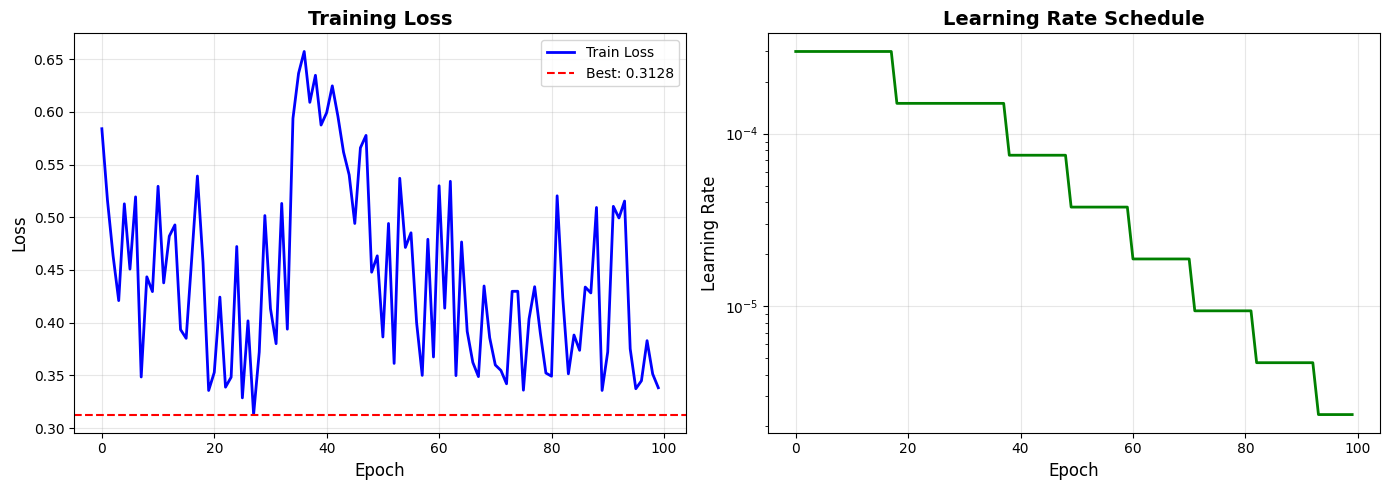


Saving final model...
✅ Model checkpoint saved to /content/drive/MyDrive/SAR_water_images_and_labels/vit_final_model.pth

Testing prediction on sample image...


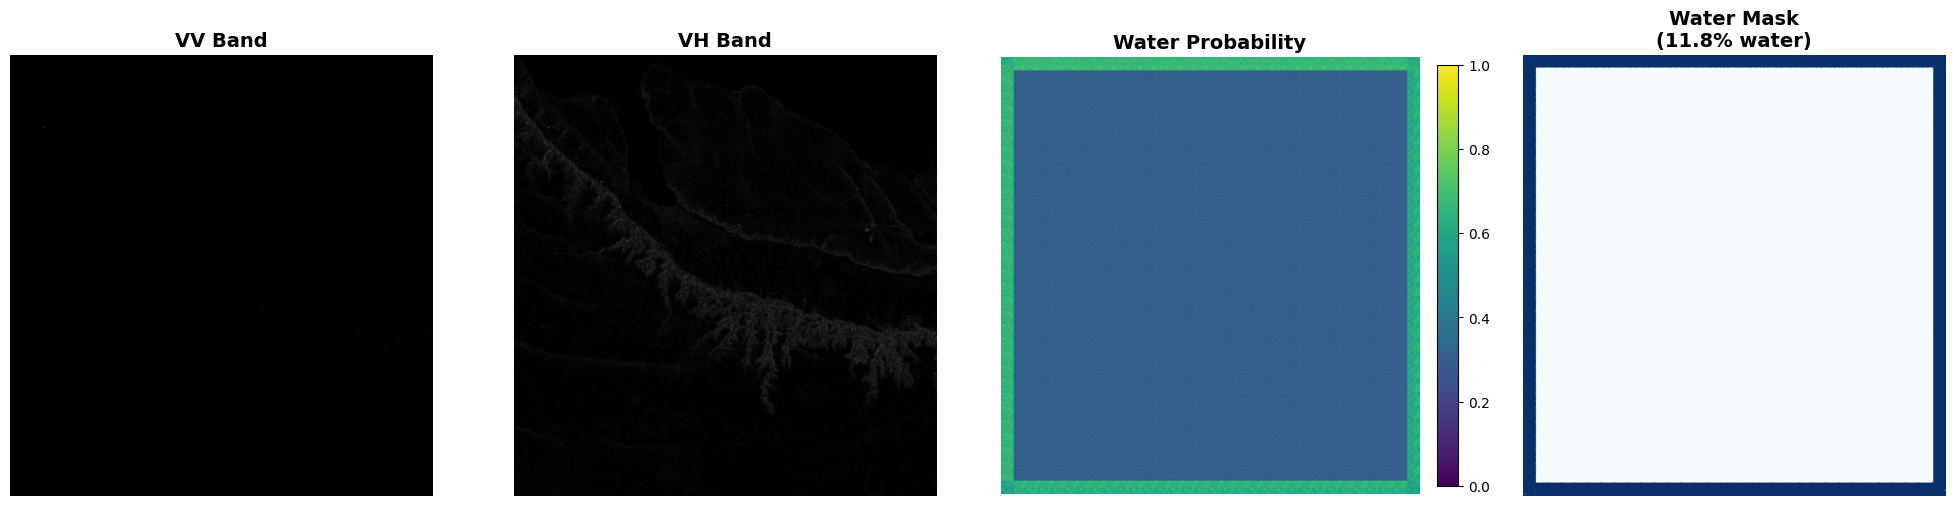


💧 Water coverage: 11.80%

Training pipeline completed successfully!


In [19]:
# ============================================
# Main Training Pipeline
# ============================================


def main():
    """Main training pipeline"""

    print("=" * 60)
    print("SAR Water Segmentation with Vision Transformer")
    print("=" * 60)

    # Get paths
    paths = Config.get_paths()

    # Find matching image-shapefile pairs
    matched_pairs = DataManager.find_image_shapefile_pairs(
        paths["images"], paths["labels"]
    )

    if len(matched_pairs) == 0:
        print("\n❌ No matching pairs found! Please check your folder structure.")
        return

    # Create dataset
    print(f"\n{'='*60}")
    print("Creating dataset with augmentation...")
    print(f"{'='*60}")
    dataset = SARSegmentationDataset(
        image_paths=[p["image"] for p in matched_pairs],
        shapefile_paths=[p["shapefile"] for p in matched_pairs],
        target_size=Config.IMAGE_SIZE,
        augment=True,
        augment_prob=Config.AUGMENT_PROB,
    )

    # Create data loader
    train_loader = DataLoader(
        dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=Config.NUM_WORKERS,
        pin_memory=True if Config.DEVICE == "cuda" else False,
    )

    print(f"   Training samples: {len(dataset)}")
    print(f"   Batch size: {Config.BATCH_SIZE}")
    print(f"   Batches per epoch: {len(train_loader)}")
    print(f"   Image size: {Config.IMAGE_SIZE}x{Config.IMAGE_SIZE}")

    # Initialize model
    print(f"\n{'='*60}")
    print("Initializing Vision Transformer model...")
    print(f"{'='*60}")
    model = ViTSegmentationModel(
        image_size=Config.IMAGE_SIZE,
        patch_size=Config.PATCH_SIZE,
        in_channels=Config.INPUT_BANDS,
        num_classes=Config.NUM_CLASSES,
        embed_dim=Config.EMBED_DIM,
        num_layers=Config.NUM_LAYERS,
        num_heads=Config.NUM_HEADS,
        mlp_ratio=Config.MLP_RATIO,
        dropout=Config.DROPOUT,
    )

    print("   Model: Vision Transformer")
    print(
        f"   Input: {Config.INPUT_BANDS} bands ({Config.IMAGE_SIZE}x{Config.IMAGE_SIZE})"
    )
    print(f"   Patch size: {Config.PATCH_SIZE}x{Config.PATCH_SIZE}")
    print(f"   Embedding dim: {Config.EMBED_DIM}")
    print(f"   Layers: {Config.NUM_LAYERS}")
    print(f"   Attention heads: {Config.NUM_HEADS}")
    print(f"   Total parameters: {model.get_num_parameters():,}")

    # Initialize trainer
    trainer = Trainer(model, train_loader, Config)

    # Train
    print(f"\n{'='*60}")
    print(f"Starting training for {Config.NUM_EPOCHS} epochs...")
    print(f"{'='*60}")
    history = trainer.train()

    # Plot training history
    print("\nPlotting training history...")
    trainer.plot_history()

    # Save final model
    print("\nSaving final model...")
    DataManager.save_model_checkpoint(
        model,
        paths["final_model"],
        metadata={
            "best_loss": trainer.best_loss,
            "epochs_trained": Config.NUM_EPOCHS,
            "final_loss": history["train_loss"][-1],
        },
    )

    # Test prediction on first image
    print(f"\n{'='*60}")
    print("Testing prediction on sample image...")
    print(f"{'='*60}")
    predictor = WaterSegmentationPredictor(
        model, device=Config.DEVICE, threshold=Config.INFERENCE_THRESHOLD
    )
    predictor.visualize_prediction(matched_pairs[0]["image"])

    print("\n" + "=" * 60)
    print("Training pipeline completed successfully!")
    print("=" * 60)





if __name__ == "__main__":
    main()

# Inference

In [20]:
# ============================================
# Inference Script
# ============================================


def run_inference(model_path: str, image_path: str, output_path: Optional[str] = None):
    """
    Run inference on a single image.

    Args:
        model_path: Path to saved model checkpoint
        image_path: Path to input SAR image
        output_path: Optional path to save visualization
    """
    # Load model
    model = DataManager.load_model_checkpoint(model_path, Config.DEVICE)

    # Create predictor
    predictor = WaterSegmentationPredictor(
        model, device=Config.DEVICE, threshold=Config.INFERENCE_THRESHOLD
    )

    # Predict and visualize
    predictor.visualize_prediction(image_path, output_path)

In [2]:
model = DataManager.load_model_checkpoint(
    path="/content/drive/MyDrive/SAR_water_images_and_labels/vit_best_model.pth",
    device=Config.DEVICE
)

# Create predictor
predictor = WaterSegmentationPredictor(
    model,
    device=Config.DEVICE,
    threshold=Config.INFERENCE_THRESHOLD
)

NameError: name 'DataManager' is not defined

In [22]:
# Load model once
# model = DataManager.load_model_checkpoint(
#     path="/content/drive/MyDrive/SAR_water_images_and_labels/vit_best_model.pth",
#     device=Config.DEVICE
# )

# # Create predictor
# predictor = WaterSegmentationPredictor(
#     model,
#     device=Config.DEVICE,
#     threshold=Config.INFERENCE_THRESHOLD
# )

# Now batch process
import glob
import rasterio

# Create output folder
output_folder = "/content/drive/MyDrive/SAR_water_images_and_labels/batch_predictions_with_vision_transformer_model/"
os.makedirs(output_folder, exist_ok=True)

# Get all test images
test_images = glob.glob("/content/drive/MyDrive/SAR_water_images_and_labels/images/*.tif")

print(f"Found {len(test_images)} images to process")
print(f"Saving predictions to: {output_folder}\n")

for img_path in tqdm(test_images, desc="Processing"):
    mask, prob, profile = predictor.predict(img_path)

    # Get original filename without path
    original_name = os.path.basename(img_path)
    base_name = os.path.splitext(original_name)[0]

    # Save to output folder
    output_path = os.path.join(output_folder, f"{base_name}_water_mask.tif")

    with rasterio.open(
        output_path, 'w',
        driver='GTiff',
        height=mask.shape[0],
        width=mask.shape[1],
        count=1,
        dtype=rasterio.uint8,
        transform=profile['transform'],
        crs=profile['crs']
    ) as dst:
        dst.write(mask, 1)

    print(f"✅ Saved: {output_path}")

print(f"\n🎉 Complete! All {len(test_images)} predictions saved to:")
print(f"   {output_folder}")

✅ Model loaded from /content/drive/MyDrive/SAR_water_images_and_labels/vit_best_model.pth
   Image size: 512
   Patch size: 16
   Embed dim: 768
   Layers: 12
Found 20 images to process
Saving predictions to: /content/drive/MyDrive/SAR_water_images_and_labels/batch_predictions_with_vision_transformer_model/



Processing:   5%|▌         | 1/20 [00:02<00:40,  2.15s/it]

✅ Saved: /content/drive/MyDrive/SAR_water_images_and_labels/batch_predictions_with_vision_transformer_model/Копия S1GRD_part_19_6_4_20250511_20250520_be938ed5cb514616ba2a222c2086fd0d_water_mask.tif


Processing:  10%|█         | 2/20 [00:04<00:37,  2.07s/it]

✅ Saved: /content/drive/MyDrive/SAR_water_images_and_labels/batch_predictions_with_vision_transformer_model/Копия S1GRD_part_19_7_10_20250921_20250930_0bdfdccbb705442c84987da90ff8672d_water_mask.tif


...

✅ Saved: /content/drive/MyDrive/SAR_water_images_and_labels/batch_predictions_with_vision_transformer_model/Копия S1GRD_part_19_10_38_20250511_20250520_6a006595cfac4ea58732a9d79e01f1a3_water_mask.tif


Processing:  95%|█████████▌| 19/20 [00:48<00:03,  3.56s/it]

✅ Saved: /content/drive/MyDrive/SAR_water_images_and_labels/batch_predictions_with_vision_transformer_model/Копия S1GRD_part_19_11_53_20250421_20250430_6eaac074e54c46a4bcdf5b019cce8164_water_mask.tif


Processing: 100%|██████████| 20/20 [00:52<00:00,  2.61s/it]

✅ Saved: /content/drive/MyDrive/SAR_water_images_and_labels/batch_predictions_with_vision_transformer_model/Копия S1GRD_part_19_10_47_20250511_20250520_198d32d50dbd4b3faad161953fd6f3b2_water_mask.tif

🎉 Complete! All 20 predictions saved to:
   /content/drive/MyDrive/SAR_water_images_and_labels/batch_predictions_with_vision_transformer_model/


Found 20 images


Processing:   0%|          | 0/20 [00:00<?, ?it/s]


NameError: name 'predictor' is not defined

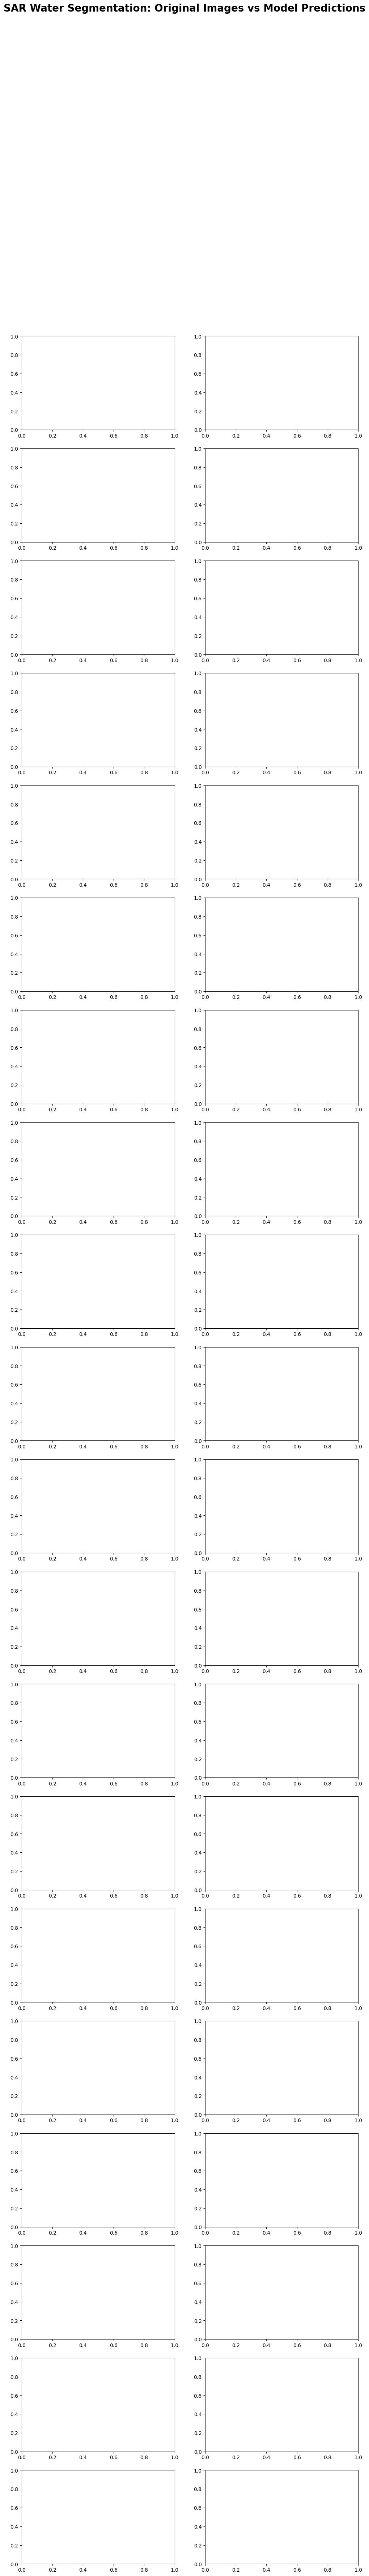

In [1]:
# Get all test images
import glob
import os
import rasterio
from tqdm import tqdm

test_images = glob.glob("/content/drive/MyDrive/SAR_water_images_and_labels/images/*.tif")
print(f"Found {len(test_images)} images")

# Limit to 20 images (for 20 rows)
test_images = test_images[:20]

# Create figure with 20 rows, 2 columns
fig, axes = plt.subplots(20, 2, figsize=(12, 80))
fig.suptitle('SAR Water Segmentation: Original Images vs Model Predictions',
             fontsize=20, fontweight='bold', y=0.995)

# Process each image
for idx, img_path in enumerate(tqdm(test_images, desc="Processing")):
    # Get prediction
    mask, prob, profile = predictor.predict(img_path)

    # Load original image for display
    with rasterio.open(img_path) as src:
        original = src.read()
        # Use VV band (first band) for display
        if original.shape[0] >= 1:
            display_img = original[0]
        else:
            display_img = original[0]

        # Normalize to [0,1] for display
        # display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())

    # LEFT COLUMN: Original image
    axes[idx, 0].imshow(display_img, cmap='gray')
    axes[idx, 0].set_title(f'Original {idx+1}', fontsize=10)
    axes[idx, 0].axis('off')

    # RIGHT COLUMN: Prediction mask
    axes[idx, 1].imshow(mask, cmap='Blues', interpolation='nearest')
    water_pct = (mask.sum() / mask.size) * 100
    axes[idx, 1].set_title(f'Prediction ({water_pct:.1f}% water)', fontsize=10)
    axes[idx, 1].axis('off')

# Adjust layout
plt.tight_layout()

# Save the figure
# output_path = "/content/drive/MyDrive/SAR_water_images_and_labels/batch_predictions_with_vision_transformer_model/20x2_comparison.png"
# os.makedirs(os.path.dirname(output_path), exist_ok=True)
# plt.savefig(output_path, dpi=150, bbox_inches='tight')
# print(f"\n✅ Figure saved to: {output_path}")

# Display in Colab
plt.show()

# Interpretability & Explainability

In [ ]:
# Run interpretability on all test images
output_folder = "/content/drive/MyDrive/SAR_water_images_and_labels/interpretability_explainability/"
os.makedirs(output_folder, exist_ok=True)

# Initialize explainers
attn_explainer = ViTAttentionRollout(model, device=Config.DEVICE)
gradcam_explainer = ViTGradCAM(model, device=Config.DEVICE)
occlusion_explainer = ViTOcclusionSensitivity(model, device=Config.DEVICE)

for idx, img_path in enumerate(tqdm(test_images[:10], desc="Interpretability")):
    # Load and prepare image
    with rasterio.open(img_path) as src:
        img = src.read()[:2]
        original_vv = img[0]
        original_vv = (original_vv - original_vv.min()) / (original_vv.max() - original_vv.min())

        for i in range(2):
            img[i] = (img[i] - img[i].min()) / (img[i].max() - img[i].min())

    img_tensor = torch.from_numpy(img).float().unsqueeze(0).to(Config.DEVICE)
    base_name = os.path.splitext(os.path.basename(img_path))[0]

    # Create comparison figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Original
    axes[0, 0].imshow(original_vv, cmap='gray')
    axes[0, 0].set_title('Original Image (VV Band)')
    axes[0, 0].axis('off')

    # Attention Rollout
    try:
        attn_map = attn_explainer.rollout(img_tensor)
        axes[0, 1].imshow(original_vv, cmap='gray')
        axes[0, 1].imshow(attn_map, cmap='hot', alpha=0.5)
        axes[0, 1].set_title('Attention Rollout')
    except Exception as e:
        axes[0, 1].text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center')
        axes[0, 1].set_title('Attention Rollout (Failed)')
    axes[0, 1].axis('off')

    # Grad-CAM
    try:
        cam_map = gradcam_explainer.generate_cam(img_tensor)
        axes[0, 2].imshow(original_vv, cmap='gray')
        axes[0, 2].imshow(cam_map, cmap='hot', alpha=0.5)
        axes[0, 2].set_title('Grad-CAM')
    except Exception as e:
        axes[0, 2].text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center')
        axes[0, 2].set_title('Grad-CAM (Failed)')
    axes[0, 2].axis('off')

    # Occlusion
    try:
        occ_map = occlusion_explainer.compute_importance_map(img_tensor)
        axes[1, 0].imshow(original_vv, cmap='gray')
        axes[1, 0].imshow(occ_map, cmap='hot', alpha=0.5)
        axes[1, 0].set_title('Occlusion Sensitivity')
    except Exception as e:
        axes[1, 0].text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center')
        axes[1, 0].set_title('Occlusion Sensitivity (Failed)')
    axes[1, 0].axis('off')

    # Prediction Mask
    try:
        mask, prob, _ = predictor.predict(img_path)
        axes[1, 1].imshow(mask, cmap='Blues')
        water_pct = (mask.sum() / mask.size) * 100
        axes[1, 1].set_title(f'Prediction ({water_pct:.1f}% water)')
    except Exception as e:
        axes[1, 1].text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center')
        axes[1, 1].set_title('Prediction (Failed)')
    axes[1, 1].axis('off')

    # Combined importance (average of all methods)
    try:
        combined = (attn_map + cam_map + occ_map) / 3
        axes[1, 2].imshow(original_vv, cmap='gray')
        axes[1, 2].imshow(combined, cmap='hot', alpha=0.5)
        axes[1, 2].set_title('Combined Importance')
    except Exception as e:
        axes[1, 2].text(0.5, 0.5, f'Error: {str(e)[:50]}', ha='center', va='center')
        axes[1, 2].set_title('Combined Importance (Failed)')
    axes[1, 2].axis('off')

    plt.suptitle(f'Interpretability Analysis: {base_name[:50]}', fontsize=14)
    plt.tight_layout()

    save_path = os.path.join(output_folder, f"{base_name}_interpretability.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

    print(f"✅ Saved: {save_path}")

print(f"\n🎉 Interpretability results saved to: {output_folder}")

# Also save individual attention maps for each method
individual_folder = os.path.join(output_folder, "individual_maps")
os.makedirs(individual_folder, exist_ok=True)

for idx, img_path in enumerate(tqdm(test_images[:10], desc="Saving individual maps")):
    # Load and prepare image
    with rasterio.open(img_path) as src:
        img = src.read()[:2]
        original_vv = img[0]
        original_vv = (original_vv - original_vv.min()) / (original_vv.max() - original_vv.min())

        for i in range(2):
            img[i] = (img[i] - img[i].min()) / (img[i].max() - img[i].min())

    img_tensor = torch.from_numpy(img).float().unsqueeze(0).to(Config.DEVICE)
    base_name = os.path.splitext(os.path.basename(img_path))[0]

    # Save individual attention map
    try:
        attn_map = attn_explainer.rollout(img_tensor)
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        ax.imshow(original_vv, cmap='gray')
        ax.imshow(attn_map, cmap='hot', alpha=0.5)
        ax.set_title('Attention Rollout')
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(individual_folder, f"{base_name}_attention.png"), dpi=150, bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"  Could not save attention map for {base_name}: {e}")

    # Save individual Grad-CAM map
    try:
        cam_map = gradcam_explainer.generate_cam(img_tensor)
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        ax.imshow(original_vv, cmap='gray')
        ax.imshow(cam_map, cmap='hot', alpha=0.5)
        ax.set_title('Grad-CAM')
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(individual_folder, f"{base_name}_gradcam.png"), dpi=150, bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"  Could not save Grad-CAM map for {base_name}: {e}")

    # Save individual occlusion map
    try:
        occ_map = occlusion_explainer.compute_importance_map(img_tensor)
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        ax.imshow(original_vv, cmap='gray')
        ax.imshow(occ_map, cmap='hot', alpha=0.5)
        ax.set_title('Occlusion Sensitivity')
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(individual_folder, f"{base_name}_occlusion.png"), dpi=150, bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"  Could not save occlusion map for {base_name}: {e}")

print(f"\n✅ Individual maps saved to: {individual_folder}")

# Some metrics

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
import torch
from tqdm import tqdm
import os
import rasterio

# ============================================
# Metric Definitions
# ============================================

class SegmentationMetrics:
    """
    Comprehensive metrics for binary segmentation evaluation.
    """

    @staticmethod
    def iou_score(y_true, y_pred):
        """
        Intersection over Union (Jaccard Index)
        IoU = TP / (TP + FP + FN)
        """
        intersection = np.logical_and(y_true, y_pred).sum()
        union = np.logical_or(y_true, y_pred).sum()
        if union == 0:
            return 1.0 if intersection == 0 else 0.0
        return intersection / union

    @staticmethod
    def dice_score(y_true, y_pred, smooth=1e-6):
        """
        Dice Coefficient (F1 Score)
        Dice = 2*TP / (2*TP + FP + FN)
        """
        intersection = np.logical_and(y_true, y_pred).sum()
        return (2. * intersection + smooth) / (y_true.sum() + y_pred.sum() + smooth)

    @staticmethod
    def dice_loss(y_true, y_pred, smooth=1e-6):
        """Dice Loss = 1 - Dice Score"""
        return 1 - SegmentationMetrics.dice_score(y_true, y_pred, smooth)

    @staticmethod
    def precision(y_true, y_pred):
        """Precision = TP / (TP + FP)"""
        tp = np.logical_and(y_true, y_pred).sum()
        fp = np.logical_and(~y_true, y_pred).sum()
        if tp + fp == 0:
            return 0.0
        return tp / (tp + fp)

    @staticmethod
    def recall(y_true, y_pred):
        """Recall = TP / (TP + FN)"""
        tp = np.logical_and(y_true, y_pred).sum()
        fn = np.logical_and(y_true, ~y_pred).sum()
        if tp + fn == 0:
            return 0.0
        return tp / (tp + fn)

    @staticmethod
    def specificity(y_true, y_pred):
        """Specificity = TN / (TN + FP)"""
        tn = np.logical_and(~y_true, ~y_pred).sum()
        fp = np.logical_and(~y_true, y_pred).sum()
        if tn + fp == 0:
            return 0.0
        return tn / (tn + fp)

    @staticmethod
    def accuracy(y_true, y_pred):
        """Accuracy = (TP + TN) / Total"""
        return accuracy_score(y_true.flatten(), y_pred.flatten())

    @staticmethod
    def f1_score(y_true, y_pred):
        """F1 Score = 2 * (Precision * Recall) / (Precision + Recall)"""
        p = SegmentationMetrics.precision(y_true, y_pred)
        r = SegmentationMetrics.recall(y_true, y_pred)
        if p + r == 0:
            return 0.0
        return 2 * p * r / (p + r)

    @staticmethod
    def balanced_accuracy(y_true, y_pred):
        """Balanced Accuracy = (Sensitivity + Specificity) / 2"""
        sens = SegmentationMetrics.recall(y_true, y_pred)  # Sensitivity = Recall
        spec = SegmentationMetrics.specificity(y_true, y_pred)
        return (sens + spec) / 2

    @staticmethod
    def pixel_error_rate(y_true, y_pred):
        """Pixel Error Rate = (FP + FN) / Total"""
        return 1 - SegmentationMetrics.accuracy(y_true, y_pred)

    @staticmethod
    def false_positive_rate(y_true, y_pred):
        """False Positive Rate = FP / (FP + TN)"""
        fp = np.logical_and(~y_true, y_pred).sum()
        tn = np.logical_and(~y_true, ~y_pred).sum()
        if fp + tn == 0:
            return 0.0
        return fp / (fp + tn)

    @staticmethod
    def false_negative_rate(y_true, y_pred):
        """False Negative Rate = FN / (FN + TP)"""
        fn = np.logical_and(y_true, ~y_pred).sum()
        tp = np.logical_and(y_true, y_pred).sum()
        if fn + tp == 0:
            return 0.0
        return fn / (fn + tp)

    @staticmethod
    def get_all_metrics(y_true, y_pred):
        """Calculate all metrics at once"""
        return {
            'iou': SegmentationMetrics.iou_score(y_true, y_pred),
            'dice_score': SegmentationMetrics.dice_score(y_true, y_pred),
            'dice_loss': SegmentationMetrics.dice_loss(y_true, y_pred),
            'precision': SegmentationMetrics.precision(y_true, y_pred),
            'recall': SegmentationMetrics.recall(y_true, y_pred),
            'specificity': SegmentationMetrics.specificity(y_true, y_pred),
            'accuracy': SegmentationMetrics.accuracy(y_true, y_pred),
            'f1_score': SegmentationMetrics.f1_score(y_true, y_pred),
            'balanced_accuracy': SegmentationMetrics.balanced_accuracy(y_true, y_pred),
            'pixel_error_rate': SegmentationMetrics.pixel_error_rate(y_true, y_pred),
            'false_positive_rate': SegmentationMetrics.false_positive_rate(y_true, y_pred),
            'false_negative_rate': SegmentationMetrics.false_negative_rate(y_true, y_pred)
        }


# ============================================
# BCE-Dice Combined Loss (as metric)
# ============================================

def bce_dice_loss(y_true, y_pred, bce_weight=0.5, dice_weight=0.5):
    """
    Combined BCE + Dice Loss as a metric.
    Assumes y_true is binary (0/1) and y_pred is binary (0/1)
    """
    # Convert to float for calculations
    y_true = y_true.astype(np.float32)
    y_pred = y_pred.astype(np.float32)

    # BCE Loss
    eps = 1e-7
    bce = -(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps)).mean()

    # Dice Loss
    intersection = (y_true * y_pred).sum()
    dice = 1 - (2. * intersection + eps) / (y_true.sum() + y_pred.sum() + eps)

    return bce_weight * bce + dice_weight * dice


# ============================================
# Evaluate Model on Test Images
# ============================================

def evaluate_model(predictor, test_images, ground_truth_folder=None, model_name="Model"):
    """
    Evaluate model predictions against ground truth masks.

    Args:
        predictor: WaterSegmentationPredictor object
        test_images: List of image paths
        ground_truth_folder: Folder containing ground truth masks (if None, skips)
        model_name: Name for logging

    Returns:
        DataFrame with metrics for each image
    """
    results = []

    for img_path in tqdm(test_images, desc=f"Evaluating {model_name}"):
        base_name = os.path.splitext(os.path.basename(img_path))[0]

        # Get prediction
        mask, prob, profile = predictor.predict(img_path)

        # Load ground truth if available
        if ground_truth_folder:
            # Try to find matching ground truth mask
            gt_path = os.path.join(ground_truth_folder, f"{base_name}_mask.tif")
            if not os.path.exists(gt_path):
                gt_path = os.path.join(ground_truth_folder, f"{base_name}.tif")

            if os.path.exists(gt_path):
                with rasterio.open(gt_path) as src:
                    y_true = src.read(1)
                y_true = (y_true > 0).astype(np.uint8)  # Ensure binary
            else:
                print(f"  Warning: No ground truth found for {base_name}")
                continue
        else:
            # If no ground truth, skip metric calculation
            results.append({
                'image': base_name,
                'model': model_name,
                'water_percentage': (mask.sum() / mask.size) * 100
            })
            continue

        # Calculate metrics
        metrics = SegmentationMetrics.get_all_metrics(y_true, mask)
        metrics['bce_dice_loss'] = bce_dice_loss(y_true, mask)
        metrics['image'] = base_name
        metrics['model'] = model_name
        metrics['water_percentage'] = (mask.sum() / mask.size) * 100
        metrics['gt_water_percentage'] = (y_true.sum() / y_true.size) * 100

        results.append(metrics)

    return pd.DataFrame(results)


# ============================================
# Run Evaluation
# ============================================

# Create output folder for metrics
metrics_folder = "/content/drive/MyDrive/SAR_water_images_and_labels/interpretability_explainability/metrics/"
os.makedirs(metrics_folder, exist_ok=True)

# Get test images
test_images = glob.glob("/content/drive/MyDrive/SAR_water_images_and_labels/images/*.tif")

# Path to ground truth masks (if you have them)
# If your shapefiles are converted to masks, point to that folder
ground_truth_folder = "/content/drive/MyDrive/SAR_water_images_and_labels/masks/"  # Update this path
# If no ground truth folder exists, set to None
# ground_truth_folder = None

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

# Evaluate BEST model
if ground_truth_folder and os.path.exists(ground_truth_folder):
    best_results = evaluate_model(best_predictor, test_images, ground_truth_folder, "Best Model")
    final_results = evaluate_model(final_predictor, test_images, ground_truth_folder, "Final Model")

    # Combine results
    all_results = pd.concat([best_results, final_results], ignore_index=True)

    # Save detailed results
    all_results.to_csv(os.path.join(metrics_folder, "all_metrics_detailed.csv"), index=False)

    # Create summary statistics
    summary = all_results.groupby('model').agg({
        'iou': ['mean', 'std', 'min', 'max'],
        'dice_score': ['mean', 'std', 'min', 'max'],
        'dice_loss': ['mean', 'std'],
        'precision': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'specificity': ['mean', 'std'],
        'accuracy': ['mean', 'std'],
        'f1_score': ['mean', 'std'],
        'balanced_accuracy': ['mean', 'std'],
        'bce_dice_loss': ['mean', 'std']
    }).round(4)

    summary.to_csv(os.path.join(metrics_folder, "metrics_summary.csv"))

    print("\n" + "=" * 60)
    print("METRICS SUMMARY")
    print("=" * 60)
    print(summary)

else:
    print("\n⚠️ No ground truth folder found. Computing only water percentages...")

    # Compute only water percentages
    for model_name, predictor_obj in [("Best Model", best_predictor), ("Final Model", final_predictor)]:
        results = []
        for img_path in tqdm(test_images, desc=model_name):
            mask, prob, profile = predictor_obj.predict(img_path)
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            results.append({
                'image': base_name,
                'model': model_name,
                'water_percentage': (mask.sum() / mask.size) * 100
            })

        df = pd.DataFrame(results)
        df.to_csv(os.path.join(metrics_folder, f"{model_name.lower().replace(' ', '_')}_water_percentages.csv"), index=False)

        print(f"\n{model_name} - Average water: {df['water_percentage'].mean():.2f}% ± {df['water_percentage'].std():.2f}%")


# ============================================
# Visualization of Metrics
# ============================================

if ground_truth_folder and os.path.exists(ground_truth_folder):
    # Create metrics visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    metrics_to_plot = ['iou', 'dice_score', 'precision', 'recall', 'specificity', 'f1_score']

    for idx, metric in enumerate(metrics_to_plot):
        row = idx // 3
        col = idx % 3

        # Box plot comparison
        best_vals = best_results[metric].values
        final_vals = final_results[metric].values

        axes[row, col].boxplot([best_vals, final_vals], labels=['Best Model', 'Final Model'])
        axes[row, col].set_ylabel(metric.upper())
        axes[row, col].set_title(f'{metric.upper()} Comparison')
        axes[row, col].grid(True, alpha=0.3)

        # Add mean values as text
        axes[row, col].text(1, best_vals.mean(), f'μ={best_vals.mean():.3f}',
                           ha='center', va='bottom', fontsize=9)
        axes[row, col].text(2, final_vals.mean(), f'μ={final_vals.mean():.3f}',
                           ha='center', va='bottom', fontsize=9)

    plt.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(metrics_folder, "metrics_comparison.png"), dpi=150, bbox_inches='tight')
    plt.show()

    # Create confusion matrix for first image
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    sample_img = test_images[0]
    base_name = os.path.splitext(os.path.basename(sample_img))[0]

    # Get predictions from both models
    best_mask, _, _ = best_predictor.predict(sample_img)
    final_mask, _, _ = final_predictor.predict(sample_img)

    # Load ground truth
    gt_path = os.path.join(ground_truth_folder, f"{base_name}_mask.tif")
    if os.path.exists(gt_path):
        with rasterio.open(gt_path) as src:
            y_true = src.read(1)
        y_true = (y_true > 0).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        for idx, (mask, title) in enumerate([(best_mask, 'Best Model'), (final_mask, 'Final Model')]):
            cm = confusion_matrix(y_true.flatten(), mask.flatten())
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Land', 'Water'])
            disp.plot(ax=axes[idx], values_format='d')
            axes[idx].set_title(f'{title} Confusion Matrix')

        # Ground truth
        axes[2].imshow(y_true, cmap='Blues')
        axes[2].set_title('Ground Truth')
        axes[2].axis('off')

        plt.suptitle(f'Confusion Matrices - {base_name[:30]}', fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(metrics_folder, f"{base_name}_confusion_matrices.png"), dpi=150, bbox_inches='tight')
        plt.show()


# ============================================
# Per-Image Metrics Table
# ============================================

if ground_truth_folder and os.path.exists(ground_truth_folder):
    # Create a formatted table of per-image metrics
    print("\n" + "=" * 80)
    print("PER-IMAGE METRICS (First 10 images)")
    print("=" * 80)

    display_cols = ['image', 'iou', 'dice_score', 'precision', 'recall', 'specificity', 'water_percentage', 'gt_water_percentage']
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)

    print("\nBEST MODEL:")
    print(best_results[display_cols].head(10).to_string(index=False))

    print("\nFINAL MODEL:")
    print(final_results[display_cols].head(10).to_string(index=False))

    # Save detailed per-image results
    best_results.to_csv(os.path.join(metrics_folder, "best_model_per_image_metrics.csv"), index=False)
    final_results.to_csv(os.path.join(metrics_folder, "final_model_per_image_metrics.csv"), index=False)

print(f"\n✅ All metrics saved to: {metrics_folder}")